# Replay Trajectory

First, connect to your robot.  

In [40]:
from reachy2_sdk import ReachySDK

reachy = ReachySDK(host='192.168.10.172')  # Replace with the actual IP

An instance already exists.
This Reachy is in REAL mode :
⚠️  Be careful, you're controlling the PHYSICAL Reachy.



Exception in thread Thread-9301 (_start_sync_in_bg):
Traceback (most recent call last):
  File "/home/nikolaraicevic/Workspace/Internal/Reachy_Pollen/reachy2/lib/python3.10/site-packages/reachy2_sdk/reachy_sdk.py", line 525, in _get_stream_update_loop
    for state_update in reachy_stub.StreamReachyState(stream_req):
  File "/home/nikolaraicevic/Workspace/Internal/Reachy_Pollen/reachy2/lib/python3.10/site-packages/grpc/_channel.py", line 543, in __next__
    return self._next()
  File "/home/nikolaraicevic/Workspace/Internal/Reachy_Pollen/reachy2/lib/python3.10/site-packages/grpc/_channel.py", line 969, in _next
Exception in thread Thread-9302 (_audit):
Traceback (most recent call last):
  File "/usr/lib/python3.10/threading.py", line 1016, in _bootstrap_inner
    self.run()
  File "/usr/lib/python3.10/threading.py", line 953, in run
    self._target(*self._args, **self._kwargs)
  File "/home/nikolaraicevic/Workspace/Internal/Reachy_Pollen/reachy2/lib/python3.10/site-packages/reachy2_s

### 🦾 Example 2: Play a sine wave on r_arm elbow

In [23]:
import time
import math

# Parameters
frequency = 0.5  # Hz, so one full movement every 2 seconds
duration = 5     # seconds
update_rate = 0.01  # 100Hz

start_time = time.time()

while time.time() - start_time < duration:
    t = time.time() - start_time
    angle = -25 + 25 * math.sin(2 * math.pi * frequency * t)  # Range: 0° to -50°
    reachy.r_arm.elbow.pitch.goal_position = angle
    reachy.send_goal_positions()
    time.sleep(update_rate)

### Recording a trajectory

In [24]:
recorded_joints = [
    reachy.r_arm._shoulder.pitch,
    reachy.r_arm._shoulder.roll,
    reachy.r_arm._elbow.yaw,
    reachy.r_arm._elbow.pitch,
    reachy.r_arm._wrist.roll,
    reachy.r_arm._wrist.pitch,
    reachy.r_arm._wrist.yaw,
]

sampling_frequency = 100    # in Hz
record_duration = 5         # in sec.

import time

trajectories = []

start = time.time()
while (time.time() - start) < record_duration:
    # Here we get the present position for all recorded joints
    current_point = [joint.present_position for joint in recorded_joints]
    # Add this point to the already recorded trajectories
    trajectories.append(current_point)

    time.sleep(1 / sampling_frequency)

### Moving and Recording

In [ ]:
import time
import math

# Parameters
frequency = 0.5             # Hz, so one full movement every 2 seconds
duration = 5                # seconds
update_rate = 0.01          # 100Hz
recorded_joints = [
    reachy.r_arm._shoulder.pitch,
    reachy.r_arm._shoulder.roll,
    reachy.r_arm._elbow.yaw,
    reachy.r_arm._elbow.pitch,
    reachy.r_arm._wrist.roll,
    reachy.r_arm._wrist.pitch,
    reachy.r_arm._wrist.yaw,
]
trajectories = []

start_time = time.time()

while time.time() - start_time < duration:
    t = time.time() - start_time
    angle = -25 + 25 * math.sin(2 * math.pi * frequency * t)  # Range: 0° to -50°
    reachy.r_arm.elbow.pitch.goal_position = angle
    reachy.send_goal_positions()

    current_point = [joint.present_position for joint in recorded_joints]
    trajectories.append(current_point)  

    time.sleep(update_rate)

### Visualize your recordings

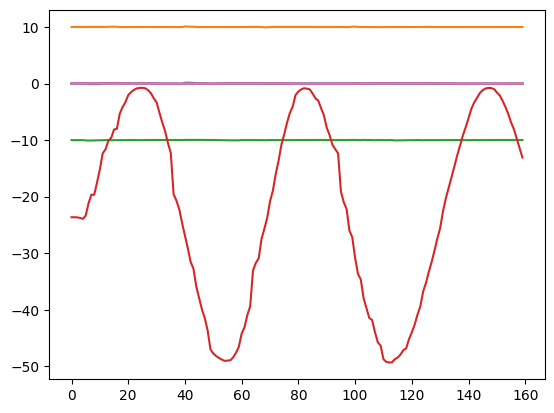

In [26]:
import numpy as np

traj_array = np.array(trajectories)

from matplotlib import pyplot as plt

plt.figure()
plt.plot(trajectories)

### Replay a recorded trajectory

##### Put the arm in the right position

In [38]:
import numpy as np

# Set all joints stiff
reachy.r_arm.turn_on()

# First trajectory point (already ordered correctly)
target = list(trajectories[0])

print("Replaying trajectory to target:", target)

# Execute motion
reachy.r_arm.goto(target, duration=3.0, wait=True)

Replaying trajectory to target: [0.00021569018225921024, 10.00121633653883, -9.999902378897248, -23.64109813263877, -0.00885998598817633, -0.015178511280033146, -0.00640850252875382]


id: 6

##### Replay the trajectory

In [39]:
import time

for joints_positions in trajectories:
    for joint, pos in zip(recorded_joints, joints_positions):
        joint.goal_position = pos
    reachy.send_goal_positions(check_positions=False)
    time.sleep(1 / sampling_frequency)

This Reachy is in REAL mode :
⚠️  Be careful, you're controlling the PHYSICAL Reachy.

